# Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")


import matplotlib.pyplot as plt
from IPython.display import HTML
import seaborn as sns
import pandas as pd
import numpy as np

from cv2 import imread


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #type:ignore
from tensorflow.keras.models import Sequential, Model #type:ignore
from tensorflow.keras import layers, models, regularizers #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D #type:ignore
from tensorflow.keras.applications import ResNet101V2 #type:ignore
from tensorflow.keras.optimizers import AdamW #type:ignore
from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.utils import plot_model #type:ignore


from sklearn.metrics import classification_report #type:ignore
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #type:ignore
from sklearn.model_selection import train_test_split #type:ignore


import pickle
from PIL import Image


import os
import random

# Set Theme

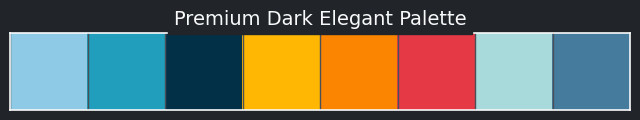

In [2]:
# Define a premium dark elegant color palette
dark_elegant_palette = [
    "#8ecae6",  # Light Blue Accent
    "#219ebc",  # Medium Blue
    "#023047",  # Deep Navy
    "#ffb703",  # Warm Yellow
    "#fb8500",  # Warm Orange
    "#e63946",  # Muted Red
    "#a8dadc",  # Soft Mint
    "#457b9d",  # Slate Blue
]

# Set a dark theme for Seaborn
sns.set_theme(
    style="darkgrid",              # Dark grid background
    palette=dark_elegant_palette,  # Custom color palette
    font="DejaVu Sans",
    rc={
        "axes.facecolor": "#212529",     # Dark background for axes
        "figure.facecolor": "#212529",   # Dark background for figure
        "axes.edgecolor": "#f8f9fa",     # Light axis lines
        "axes.labelcolor": "#f8f9fa",    # Light axis labels
        "text.color": "#f8f9fa",         # Light text
        "xtick.color": "#f8f9fa",        # Light tick labels
        "ytick.color": "#f8f9fa",
        "grid.color": "#495057",         # Muted gridlines
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.figsize": (8, 5),
        "axes.linewidth": 1.2,
    }
)

# Apply the palette to Matplotlib
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=dark_elegant_palette)

# Preview the palette
sns.palplot(dark_elegant_palette)
plt.title("Premium Dark Elegant Palette", fontsize=14, color="#f8f9fa", backgroundcolor="#212529")
plt.show()

# Get Data

In [3]:
data_path = 'dataset/garbage-dataset'

print(f"Number of class: {len(os.listdir(data_path))}")

Number of class: 7


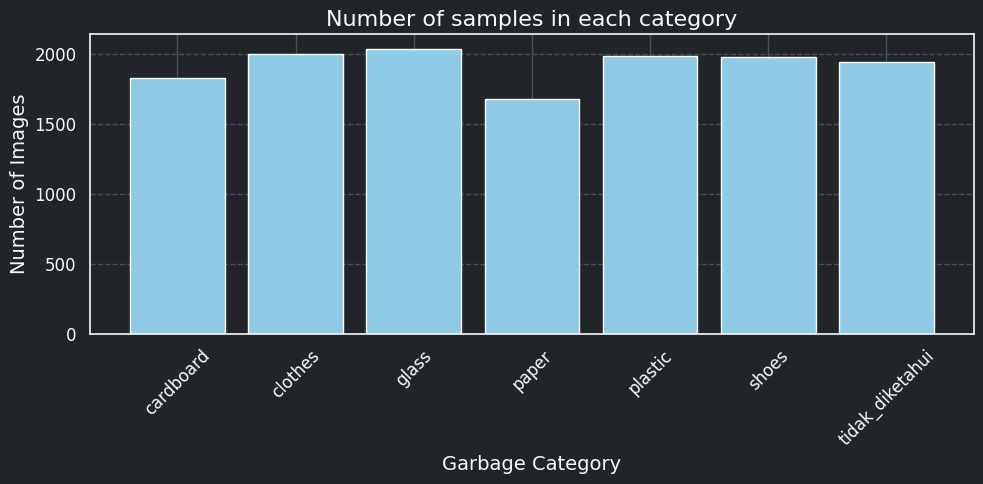

In [4]:
class_counts = { category: len(os.listdir(os.path.join(data_path, category))) for category in os.listdir(data_path) }

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Number of samples in each category")
plt.xlabel("Garbage Category")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--")
plt.tight_layout()
plt.show()

In [5]:
def plot_samples(path_of_dataset):
    classes = os.listdir(path_of_dataset)
    random_imgs = []
    for clas in classes:
        class_path = os.path.join(path_of_dataset, clas)
        random_img = random.choice(os.listdir(class_path))  
        image_path = os.path.join(class_path, random_img)
        random_imgs.append(image_path)

    plt.figure(figsize=(20, 15))  
    for i, image_path in enumerate(random_imgs):
        plt.subplot(2, 5, i+1) 
        img = imread(image_path)
        plt.imshow(img)
        plt.title(os.path.basename(os.path.dirname(image_path)))  
        plt.axis('off') 
    
    plt.tight_layout()  
    plt.show()

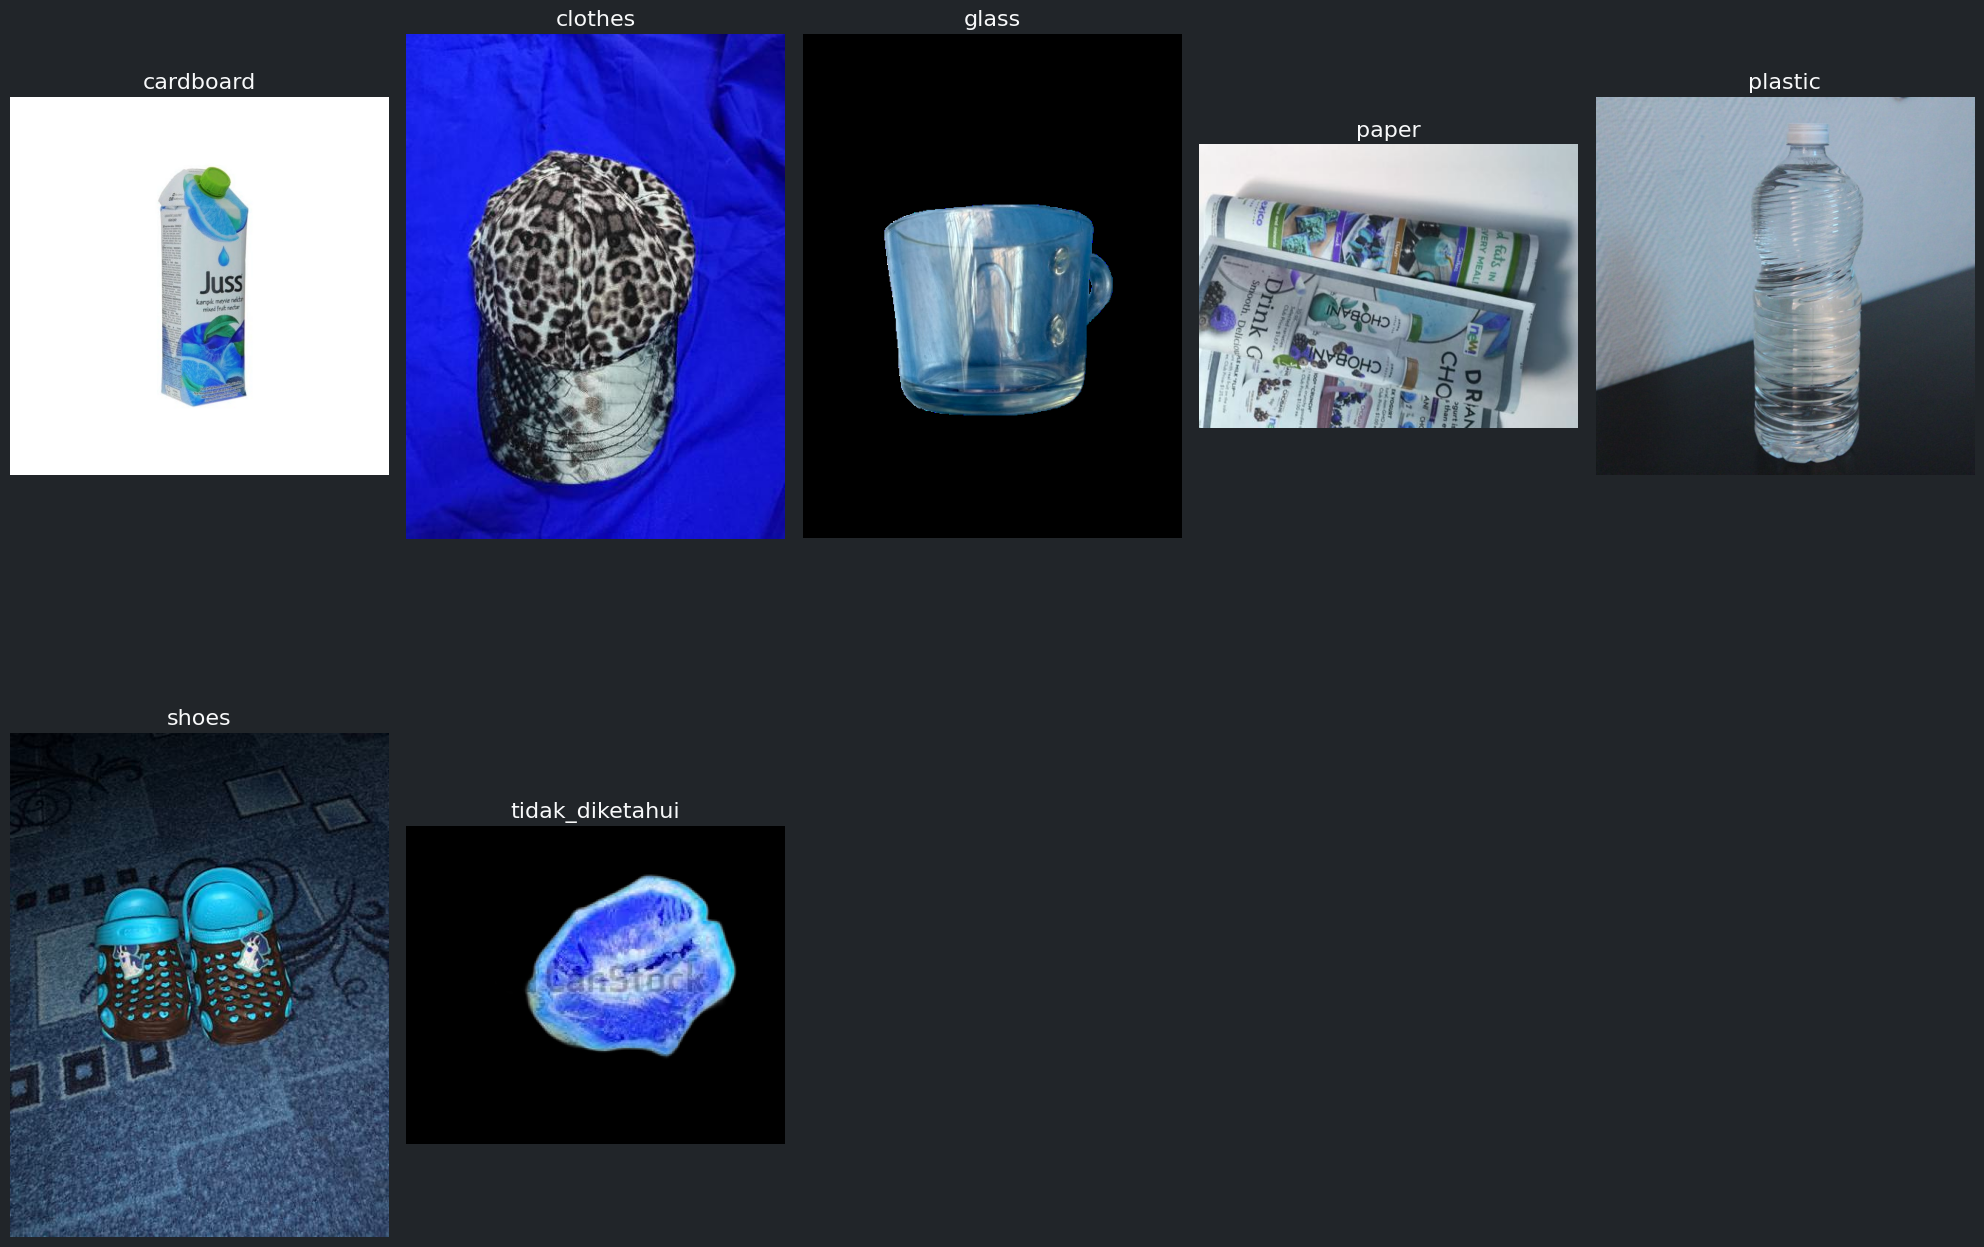

In [6]:
plot_samples(data_path)


In [7]:
def get_shapes(base_path):
    image_shapes = []
    
    for clas in os.listdir(base_path):
        class_path = os.path.join(base_path, clas)
        for img_file in os.listdir(class_path)[:50]: 
            img_path = os.path.join(class_path, img_file)
            with Image.open(img_path) as img:
                image_shapes.append(img.size)
    
    # Convert to numpy array for statistics
    widths, heights = zip(*image_shapes)
    
    print(f"Average image width: {np.mean(widths):.2f}, height: {np.mean(heights):.2f}")
    print(f"Min size: {np.min(widths)}x{np.min(heights)} | Max size: {np.max(widths)}x{np.max(heights)}")

In [8]:
get_shapes(data_path)

Average image width: 426.01, height: 422.77
Min size: 127x129 | Max size: 7786x6283


In [9]:
target_size = (224, 224)
batch_size=32
seed=42

# Split Data

In [33]:
def create_datasets(data_path, target_size=(224, 224), batch_size=32, seed=42):
    """
    Creates train/val/test datasets 
    Returns: (train_gen, val_gen, test_gen, class_names)
    """
    # Get all image paths and labels
    image_paths = []
    labels = []
    class_names = sorted(os.listdir(data_path))
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_path, class_name)
        for img_file in os.listdir(class_dir):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_name)  # Using string labels for flow_from_dataframe
    
    # Create dataframe
    df = pd.DataFrame({'filename': image_paths, 'class': labels})
    
    # Split into train (70%), val (20%), test (10%)
    train_df, temp_df = train_test_split(
        df, 
        test_size=0.3, 
        random_state=seed,
        stratify=df['class']
    )
    
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.333,  # 0.333 * 0.3 = 0.1 (10%)
        random_state=seed,
        stratify=temp_df['class']
    )

    # Create generators
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        brightness_range=[0.9, 1.1],
        horizontal_flip=True,
        fill_mode='nearest'
    )   
    
    val_test_datagen = ImageDataGenerator(
        rescale=1./255
    )
    
    # Flow from dataframe
    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filename',
        y_col='class',
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        seed=seed
    )
    
    val_gen = val_test_datagen.flow_from_dataframe(
        val_df,
        x_col='filename',
        y_col='class',
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
    
    test_gen = val_test_datagen.flow_from_dataframe(
        test_df,
        x_col='filename',
        y_col='class',
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_gen, val_gen, test_gen, class_names

In [34]:
train, validation, test, class_names = create_datasets(data_path)

Found 9410 validated image filenames belonging to 7 classes.
Found 2690 validated image filenames belonging to 7 classes.
Found 1344 validated image filenames belonging to 7 classes.


# Modeling With ResNet 101V2

## Feature Extraction

In [13]:
base_model = ResNet101V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [14]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)  

predictions = Dense(7, activation='softmax')(x) 
model_ResNet101V2= Model(inputs=base_model.input, outputs=predictions)



In [15]:
model_ResNet101V2.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_conv[0][0]']          
                                                                                              

In [ ]:
plot_model(
    model_ResNet101V2,
    to_file='model.png',    
    show_shapes=True,    
    show_layer_names=True
)

In [17]:
optimizer = AdamW(learning_rate=1e-4)  # Higher learning rate

model_ResNet101V2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [18]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [19]:
history_ResNet101V2 = model_ResNet101V2.fit(
    train,
    epochs=25,
    validation_data=validation,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/25


295/295 [==============================] - 2396s 8s/step - loss: 0.8935 - accuracy: 0.6943 - val_loss: 0.3681 - val_accuracy: 0.8740 - lr: 1.0000e-04
Epoch 2/25
295/295 [==============================] - 2708s 9s/step - loss: 0.4357 - accuracy: 0.8554 - val_loss: 0.2968 - val_accuracy: 0.8985 - lr: 1.0000e-04
Epoch 3/25
295/295 [==============================] - 1575s 5s/step - loss: 0.3714 - accuracy: 0.8753 - val_loss: 0.2743 - val_accuracy: 0.9108 - lr: 1.0000e-04
Epoch 4/25
295/295 [==============================] - 797s 3s/step - loss: 0.3272 - accuracy: 0.8903 - val_loss: 0.2596 - val_accuracy: 0.9123 - lr: 1.0000e-04
Epoch 5/25
295/295 [==============================] - 957s 3s/step - loss: 0.2996 - accuracy: 0.8989 - val_loss: 0.2471 - val_accuracy: 0.9167 - lr: 1.0000e-04
Epoch 6/25
295/295 [==============================] - 1340s 5s/step - loss: 0.2857 - accuracy: 0.9011 - val_loss: 0.2265 - val_accuracy: 0.9219 - lr: 1.0000e-04
Epoch 7/25
295/295 [==============

In [20]:
test_loss, test_acc = model_ResNet101V2.evaluate(test, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

42/42 [==============================] - 85s 2s/step - loss: 0.1928 - accuracy: 0.9412
Test Accuracy: 94.12%
Test Loss: 0.1928


In [21]:
def plot_training_curves(history):
    """
    Plots training & validation loss and accuracy.
    """
    # Extract data
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Create plots
    plt.figure(figsize=(14, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png")
    print("✅ Training curves saved as training_curves.png")
    plt.show()



✅ Training curves saved as training_curves.png


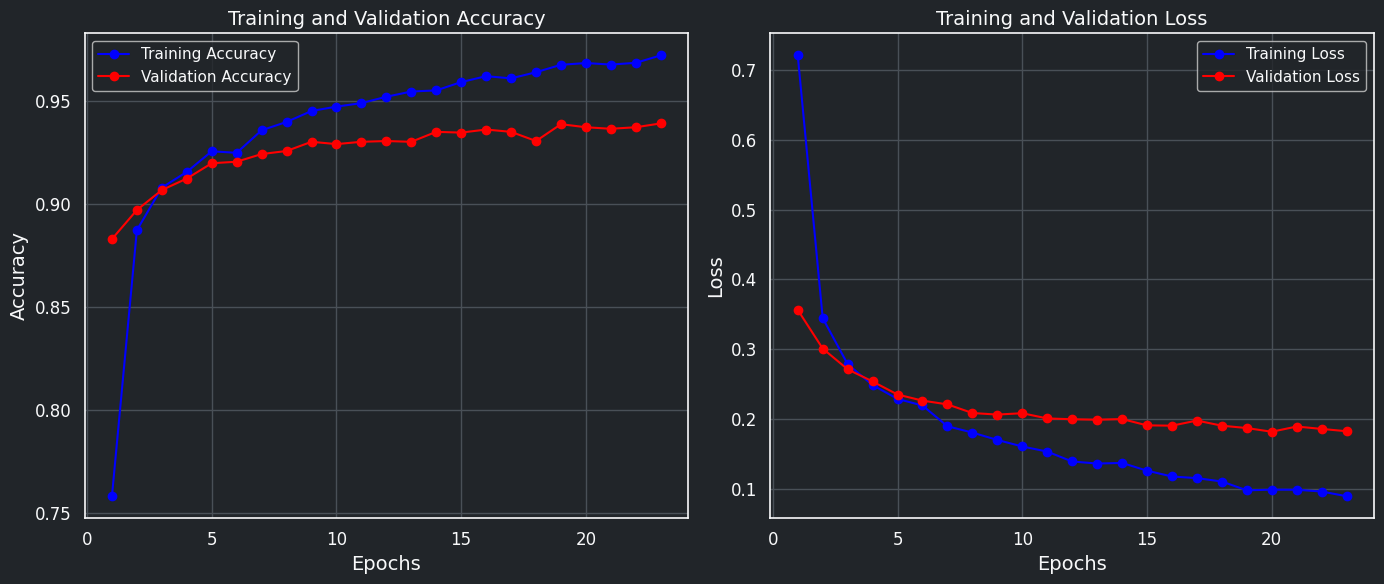

In [21]:
plot_training_curves(history_ResNet101V2)


In [22]:
def evaluate_model(model, test_gen, class_labels, save_prefix="model"):
    """
    Evaluates the model on a test set and saves evaluation artifacts.
    
    Args:
        model: Trained Keras model
        test_gen: Test data generator
        class_labels: List of class names
        save_prefix: Prefix for saved files (default 'model')
    """
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_gen, verbose=1)
    print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
    print(f"✅ Test Loss: {test_loss:.4f}")

    # Predict
    y_pred_probs = model.predict(test_gen)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    # Classification Report
    report = classification_report(y_true, y_pred, target_names=class_labels)
    print("\n📄 Classification Report:\n")
    print(report)

    # Save classification report
    report_file = f"{save_prefix}_classification_report.txt"
    with open(report_file, "w") as f:
        f.write(report)
    print(f"✅ Classification report saved to {report_file}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()

    cm_file = f"{save_prefix}_confusion_matrix.png"
    plt.savefig(cm_file)
    print(f"✅ Confusion matrix saved to {cm_file}")
    plt.show()

42/42 [==============================] - 84s 2s/step - loss: 0.1928 - accuracy: 0.9412
✅ Test Accuracy: 94.12%
✅ Test Loss: 0.1928
42/42 [==============================] - 89s 2s/step

📄 Classification Report:

                 precision    recall  f1-score   support

      cardboard       0.94      0.92      0.93       183
        clothes       0.98      0.99      0.99       199
          glass       0.95      0.95      0.95       204
          paper       0.90      0.93      0.91       168
        plastic       0.92      0.91      0.92       198
          shoes       0.96      0.99      0.98       198
tidak_diketahui       0.93      0.89      0.91       194

       accuracy                           0.94      1344
      macro avg       0.94      0.94      0.94      1344
   weighted avg       0.94      0.94      0.94      1344

✅ Classification report saved to garbage_classifier_EfficientB3_classification_report.txt
✅ Confusion matrix saved to garbage_classifier_EfficientB3_confusion_

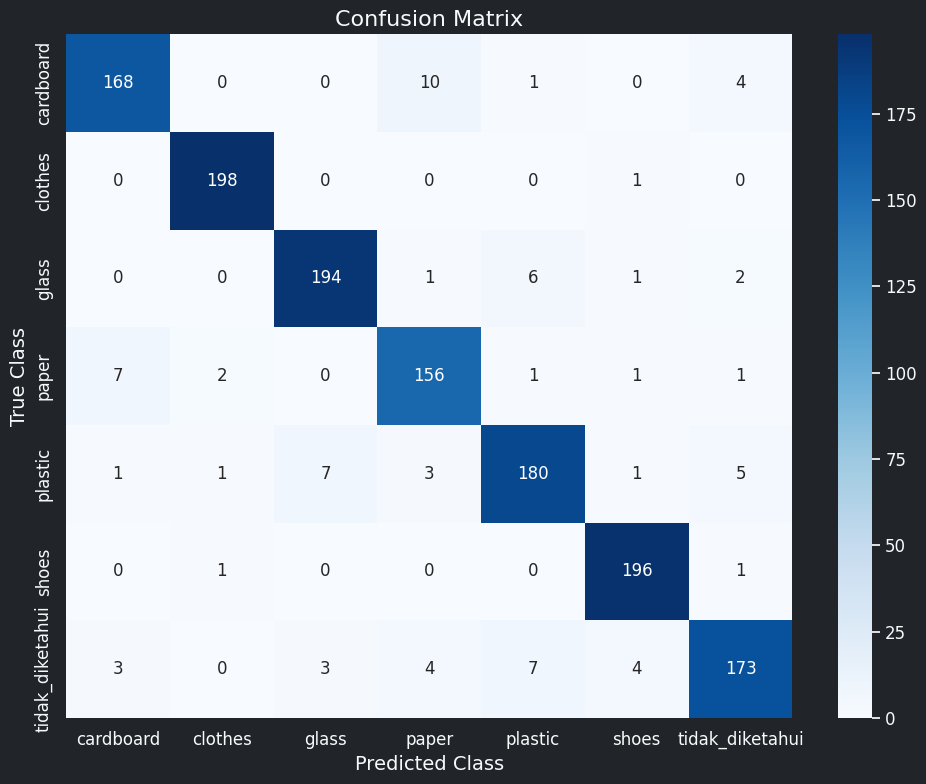

In [23]:
evaluate_model(model_ResNet101V2, test, class_names, save_prefix="garbage_classifier_EfficientB3")


In [39]:
model_ResNet101V2.save("garbage_classifier_model_ResNet101V2.keras")
model_ResNet101V2.save("garbage_classifier_model_ResNet101V2.h5")

## Fine Tuning

In [40]:
print(len(base_model.layers))


377


In [41]:
# Unfreeze top 30% of layers for fine-tuning
fine_tune_at = int(len(base_model.layers) * 0.7)  # freeze bottom 70%
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

In [42]:
model_ResNet101V2.compile(
              optimizer=AdamW(1e-5), 
              loss='categorical_crossentropy', 
              metrics=['accuracy']
)

In [43]:
finetuned_history_ResNet101V2 = model_ResNet101V2.fit(
    train,
    epochs=10,
    validation_data=validation,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
295/295 [==============================] - 1230s 4s/step - loss: 0.3356 - accuracy: 0.8889 - val_loss: 0.1996 - val_accuracy: 0.9323 - lr: 1.0000e-05
Epoch 2/10
295/295 [==============================] - 1195s 4s/step - loss: 0.2416 - accuracy: 0.9204 - val_loss: 0.1868 - val_accuracy: 0.9364 - lr: 1.0000e-05
Epoch 3/10
295/295 [==============================] - 1310s 4s/step - loss: 0.1935 - accuracy: 0.9363 - val_loss: 0.1682 - val_accuracy: 0.9457 - lr: 1.0000e-05
Epoch 4/10
295/295 [==============================] - 1496s 5s/step - loss: 0.1735 - accuracy: 0.9408 - val_loss: 0.1586 - val_accuracy: 0.9472 - lr: 1.0000e-05
Epoch 5/10
295/295 [==============================] - 1170s 4s/step - loss: 0.1433 - accuracy: 0.9524 - val_loss: 0.1523 - val_accuracy: 0.9513 - lr: 1.0000e-05
Epoch 6/10
295/295 [==============================] - 1086s 4s/step - loss: 0.1285 - accuracy: 0.9580 - val_loss: 0.1486 - val_accuracy: 0.9517 - lr: 1.0000e-05
Epoch 7/10
295/295 [==============

In [44]:
finetuned_test_loss, finetuned_test_acc = model_ResNet101V2.evaluate(test, verbose=1)
print(f"Test Accuracy: {finetuned_test_acc*100:.2f}%")
print(f"Test Loss: {finetuned_test_loss:.4f}")

42/42 [==============================] - 77s 2s/step - loss: 0.1519 - accuracy: 0.9561
Test Accuracy: 95.61%
Test Loss: 0.1519


In [45]:
def plot_training_curves(history, save_prefix="model"):
    """
    Plots training & validation loss and accuracy.
    """
    # Extract data
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Create plots
    plt.figure(figsize=(14, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{save_prefix} training_curves.png")
    print("✅ Training curves saved as training_curves.png")
    plt.show()

✅ Training curves saved as training_curves.png


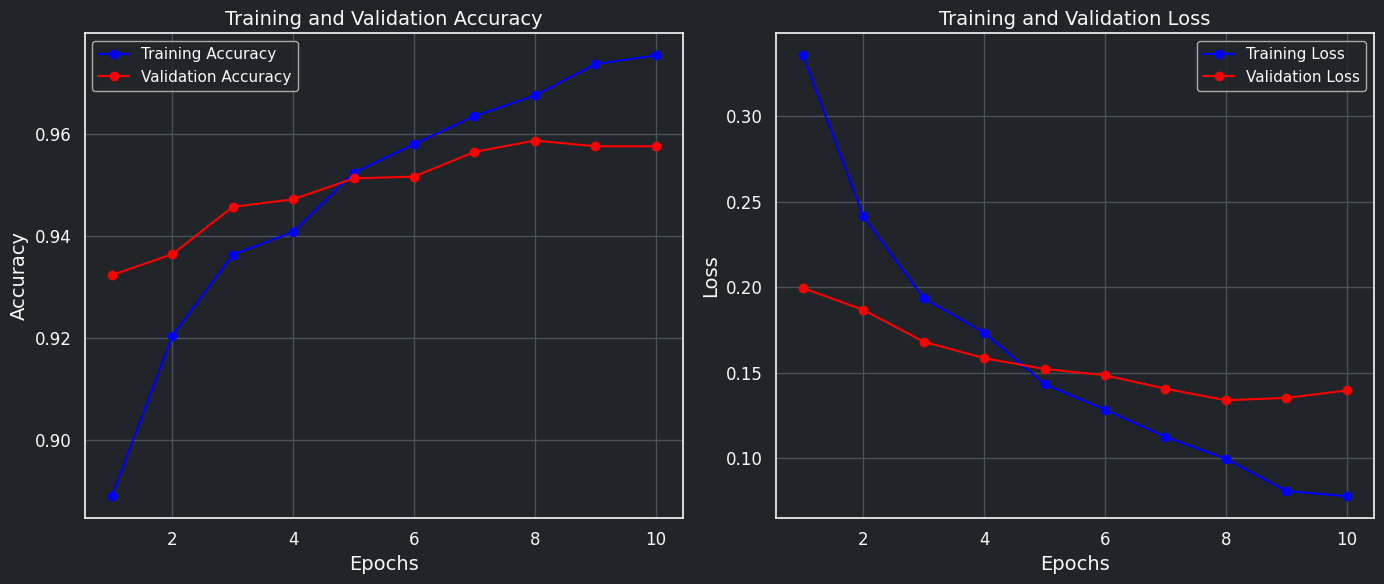

In [46]:
plot_training_curves(finetuned_history_ResNet101V2, save_prefix = 'fine_tuned')


In [47]:
def evaluate_model(model, test_gen, class_labels, save_prefix="model"):
    """
    Evaluates the model on a test set and saves evaluation artifacts.
    
    Args:
        model: Trained Keras model
        test_gen: Test data generator
        class_labels: List of class names
        save_prefix: Prefix for saved files (default 'model')
    """
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_gen, verbose=1)
    print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
    print(f"✅ Test Loss: {test_loss:.4f}")

    # Predict
    y_pred_probs = model.predict(test_gen)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    # Classification Report
    report = classification_report(y_true, y_pred, target_names=class_labels)
    print("\n📄 Classification Report:\n")
    print(report)

    # Save classification report
    report_file = f"{save_prefix}_classification_report.txt"
    with open(report_file, "w") as f:
        f.write(report)
    print(f"✅ Classification report saved to {report_file}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()

    cm_file = f"{save_prefix}_confusion_matrix.png"
    plt.savefig(cm_file)
    print(f"✅ Confusion matrix saved to {cm_file}")
    plt.show()

42/42 [==============================] - 78s 2s/step - loss: 0.1519 - accuracy: 0.9561
✅ Test Accuracy: 95.61%
✅ Test Loss: 0.1519
42/42 [==============================] - 79s 2s/step

📄 Classification Report:

                 precision    recall  f1-score   support

      cardboard       0.97      0.92      0.94       183
        clothes       0.98      0.99      0.99       199
          glass       0.97      0.98      0.97       204
          paper       0.91      0.95      0.93       168
        plastic       0.95      0.94      0.95       198
          shoes       0.97      1.00      0.99       198
tidak_diketahui       0.94      0.90      0.92       194

       accuracy                           0.96      1344
      macro avg       0.96      0.96      0.96      1344
   weighted avg       0.96      0.96      0.96      1344

✅ Classification report saved to finetuned_garbage_classifier_classification_report.txt
✅ Confusion matrix saved to finetuned_garbage_classifier_confusion_matr

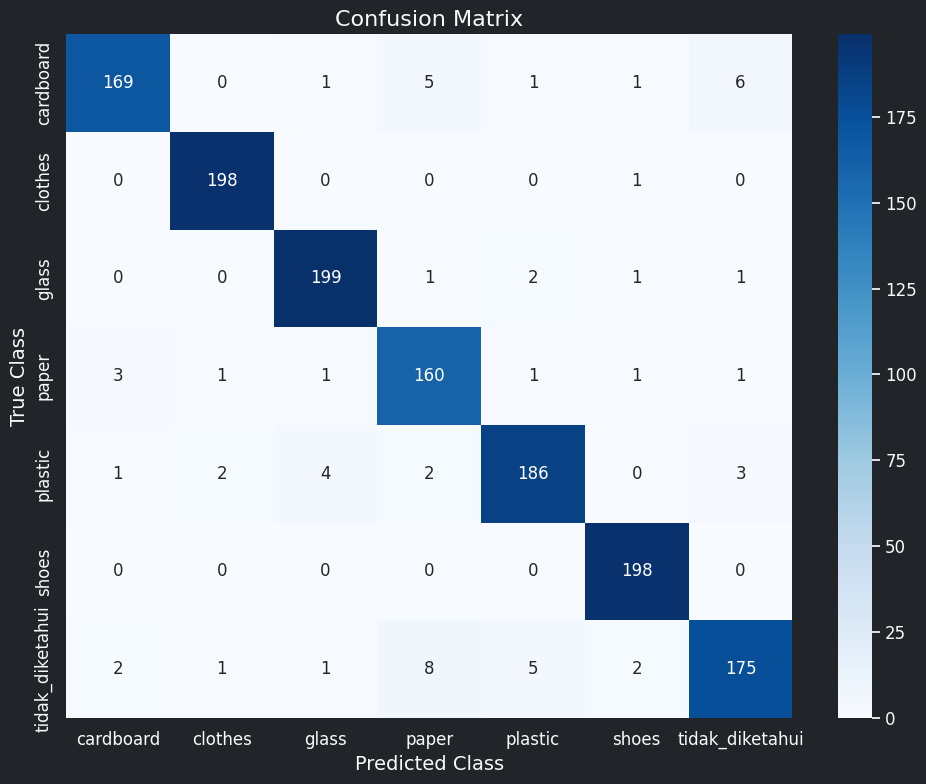

In [48]:
evaluate_model(model_ResNet101V2, test, class_names, save_prefix="finetuned_garbage_classifier")


## Saving Details

In [49]:
# Save fine-tuned model as .h5 for deployment
model_ResNet101V2.save("finetuned_garbage_classifier_model_ResNet101V2.h5")
print("✅ Model fine-tuned berhasil disimpan ke .h5!")

✅ Model fine-tuned berhasil disimpan ke .h5!


In [1]:
model_ResNet101V2.save("finetuned_garbage_classifier_model_ResNet101V2.keras")
print("✅ Model saved")

NameError: name 'model_ResNet101V2' is not defined

In [50]:
with open("finetuned_summary.txt", "w", encoding="utf-8") as f:
    model_ResNet101V2.summary(print_fn=lambda x: f.write(x + "\n"))

print("✅ Model summary saved to finetuned_summary.txt")


✅ Model summary saved to finetuned_summary.txt


In [51]:
with open("finetuned_history.pkl", "wb") as f:
    pickle.dump(finetuned_history_ResNet101V2.history, f)
print("✅ Training history saved to finetuned_history.pkl")

✅ Training history saved to finetuned_history.pkl
